# Imports

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
from model import EvacuationModel
import json
from pathlib import Path
import os
import math


%matplotlib inline
plt.style.use('default')

# Functions for loading and aggreagating experiment data

In [7]:
def load_experiment_results(exp_dir, load_detailed_data=False, parameter_filter=None):
    """
    Load results from a completed experiment with flexible data access.
    
    Args:
        exp_dir: Path to experiment directory
        load_detailed_data: If True, also load model/agent dataframes for each run
        parameter_filter: Dict to filter runs, e.g., {"v0": 2.0} or {"leader_proportion": 0.1}
    
    Returns:
        results_dict: Dictionary containing all experiment data
    """
    exp_dir = Path(exp_dir)
    
    # Load basic experiment info
    with open(exp_dir / "experiment_config.json", "r") as f:
        config = json.load(f)
    
    # Load summary and detailed results
    summary_df = pd.read_csv(exp_dir / "summary_results.csv")
    detailed_df = pd.read_csv(exp_dir / "detailed_results.csv")
    
    # Load raw results if available
    all_results = None
    if (exp_dir / "all_results.json").exists():
        with open(exp_dir / "all_results.json", "r") as f:
            all_results = json.load(f)
    
    print(f"Loaded experiment: {config['description']}")
    print(f"Date: {config['experiment_date']}")
    print(f"Total runs: {len(detailed_df)}")
    
    # Build results dictionary
    results = {
        "config": config,
        "summary_df": summary_df,
        "detailed_df": detailed_df,
        "all_results": all_results,
        "exp_dir": exp_dir
    }
    
    # Identify the varied parameter from the data
    varied_params = []
    for col in detailed_df.columns:
        if col not in ['run', 'total_time', 'evacuated', 'injured', 'evacuation_rate', 
                      'flow_rate', 'simulation_steps', 'computation_time', 
                      'final_agents_remaining', 'timeout']:
            if detailed_df[col].nunique() > 1:
                varied_params.append(col)
    
    if varied_params:
        print(f"Varied parameter(s): {', '.join(varied_params)}")
        results["varied_parameters"] = varied_params
    
    # Apply parameter filter if specified
    if parameter_filter:
        filtered_df = detailed_df.copy()
        for param, value in parameter_filter.items():
            if param in filtered_df.columns:
                filtered_df = filtered_df[filtered_df[param] == value]
                print(f"Filtered to {param} = {value}: {len(filtered_df)} runs")
            else:
                print(f"Warning: Parameter '{param}' not found in data")
        results["filtered_df"] = filtered_df
    
    # Load detailed simulation data if requested
    if load_detailed_data:
        print(f"Loading detailed simulation data...")
        detailed_data = load_simulation_data(exp_dir, parameter_filter)
        results["simulation_data"] = detailed_data
        print(f"Loaded simulation data for {len(detailed_data)} runs")
    
    return results

def load_simulation_data(exp_dir, parameter_filter=None):
    """
    Load model and agent dataframes for specific runs.
    
    Args:
        exp_dir: Path to experiment directory
        parameter_filter: Dict to filter which runs to load, e.g., {"v0": 2.0}
    
    Returns:
        simulation_data: Dict with run info and dataframes
    """
    exp_dir = Path(exp_dir)
    simulation_data = {}
    
    # Get all run directories
    run_dirs = [d for d in exp_dir.iterdir() if d.is_dir() and d.name.startswith(('v0_', 'leader_', 'param_', 'fire_'))]
    
    for run_dir in run_dirs:
        # Load run configuration
        run_config_file = run_dir / "run_config.json"
        if not run_config_file.exists():
            continue
            
        with open(run_config_file, "r") as f:
            run_config = json.load(f)
        
        # Apply filter if specified
        if parameter_filter:
            skip_run = False
            for param, value in parameter_filter.items():
                # Check in agent_params first, then model_params, then direct keys
                agent_value = run_config.get("agent_params", {}).get(param)
                model_value = run_config.get("model_params", {}).get(param)
                actual_value = run_config.get(param + "_actual")
                direct_value = run_config.get(param)
                
                run_value = agent_value or model_value or actual_value or direct_value
                
                if run_value != value:
                    skip_run = True
                    break
            
            if skip_run:
                continue
        
        # Load the dataframes
        model_data_file = run_dir / "model_data.pkl"
        agent_data_file = run_dir / "agent_data.pkl"
        
        run_data = {
            "run_config": run_config,
            "run_dir": run_dir,
            "run_name": run_dir.name
        }
        
        if model_data_file.exists():
            with open(model_data_file, "rb") as f:
                run_data["model_df"] = pickle.load(f)
        
        if agent_data_file.exists():
            with open(agent_data_file, "rb") as f:
                run_data["agent_df"] = pickle.load(f)
        
        simulation_data[run_dir.name] = run_data
    
    return simulation_data

def load_combined_model_df(exp_dir, parameter_name="leader_proportion", parameter_values=None, additional_filters=None):
    """
    Combine model_df from all runs for selected parameter values and filters into a single DataFrame.
    Adds columns for parameter value and run.
    """
    # first step is just checking if the parameter values provided are the same as the ones we recorded
    results = load_experiment_results(exp_dir)
    if parameter_name not in results['detailed_df'].columns:
        print(f"Parameter '{parameter_name}' not found in data")
        return None

    available_values = sorted(results['detailed_df'][parameter_name].unique())
    if parameter_values is None:
        parameter_values = available_values
    else:
        parameter_values = [v for v in parameter_values if v in available_values]

    dfs = []
    # load data for the specific parameter values
    for param_value in parameter_values:
        param_filter = {parameter_name: param_value}
        if additional_filters:
            param_filter.update(additional_filters)
        param_results = load_experiment_results(
            exp_dir, load_detailed_data=True, parameter_filter=param_filter
        )
        for run_name, run_data in param_results.get('simulation_data', {}).items():
            if 'model_df' not in run_data:
                continue
            df = run_data['model_df'].copy()
            df = df.reset_index(drop=True)
            df[parameter_name] = param_value
            df['run_name'] = run_name
            dfs.append(df)
    if not dfs:
        print("No model data found for the selected conditions.")
        return None
    combined_df = pd.concat(dfs, ignore_index=True)
    return combined_df

# Generic Plot Function

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

def plot_by_parameter(
    combined_df,
    parameter_name,
    ycol,
    title,
    ylabel,
    kind='line',
    cumulative=False,
    smooth=False,
    dt=0.1,
    max_steps=1000,
    save_dir=None,
    show=True
):
    """
    Plot an averaged metric over time grouped by parameter value,
    and optionally save each plot as a PDF.

    Args:
        combined_df: Combined dataframe with model data
        parameter_name: Parameter varied across runs (e.g. 'leader_proportion')
        ycol: Column to plot on y-axis
        title: Figure title
        ylabel: Y-axis label
        kind: Plot type
        cumulative: If True, compute cumulative sum over time
        smooth: If True, apply moving average smoothing
        dt: Time step (s)
        max_steps: Max steps to align all runs
        save_dir: Optional directory path to save the plot as PDF
        show: If True, display the plot after saving
    """
    plt.figure(figsize=(10, 5))
    param_values = sorted(combined_df[parameter_name].unique())
    for param_value in param_values:
        df = combined_df[combined_df[parameter_name] == param_value]
        runs = []
        for run_name, run_df in df.groupby('run_name'):
            run_df = run_df.copy()
            run_df['step'] = np.arange(len(run_df))
            run_df = run_df.set_index('step')
            run_df = run_df.reindex(range(max_steps), method='ffill')
            runs.append(run_df[ycol].values)
        runs = np.array(runs)
        y = np.nanmean(runs, axis=0)
        t = np.arange(max_steps) * dt
        if cumulative:
            y = np.nancumsum(y)
        if smooth:
            window = max(1, int(2.0 / dt))
            y = pd.Series(y).rolling(window, min_periods=1).mean().values
        # Label formatting
        if parameter_name == "leader_proportion":
            label = f"{param_value:.0%} leaders"
        elif parameter_name == "fire_enabled":
            label = "Fire" if param_value else "No Fire"
        elif parameter_name == "exit_preset":
            label = str(param_value).replace("_", " ").title()
        else:
            label = f"{parameter_name}={param_value}"
        plt.plot(t, y, linewidth=2, label=label)

    plt.title(title)
    plt.xlabel('Time [s]')
    plt.ylabel(ylabel)
    plt.legend(fontsize=8, ncol=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # --- Save to PDF ---
    if save_dir:
        Path(save_dir).mkdir(parents=True, exist_ok=True)
        safe_title = title.lower().replace(" ", "_").replace("/", "-")
        filename = f"{safe_title}_{ycol}.pdf"
        filepath = Path(save_dir) / filename
        plt.savefig(filepath, format='pdf', bbox_inches='tight')
        print(f"Saved plot to: {filepath}")

    if show:
        plt.show()
    else:
        plt.close()

# Plots

## Plot the impact of different leader proportions on evacuation progress, average speed and number of injuries

Loaded experiment: Comprehensive extended agent experiment testing fire, multiple exits, and leadership effects on evacuation dynamics
Date: 2025-10-20T14:38:38.228766
Total runs: 300
Varied parameter(s): fire_enabled, exit_preset, num_exits, leader_proportion, num_leaders, seed, remaining_agents, overall_flow_rate, leaders_evacuated, leaders_remaining, leader_evacuation_rate, leader_flow_rate, injured_total, injured_rate, injured_fire, injured_smoke, injured_pressure, exit0_usage, exit1_usage, exit2_usage, exit_balance
Loaded experiment: Comprehensive extended agent experiment testing fire, multiple exits, and leadership effects on evacuation dynamics
Date: 2025-10-20T14:38:38.228766
Total runs: 300
Varied parameter(s): fire_enabled, exit_preset, num_exits, leader_proportion, num_leaders, seed, remaining_agents, overall_flow_rate, leaders_evacuated, leaders_remaining, leader_evacuation_rate, leader_flow_rate, injured_total, injured_rate, injured_fire, injured_smoke, injured_pressure, 

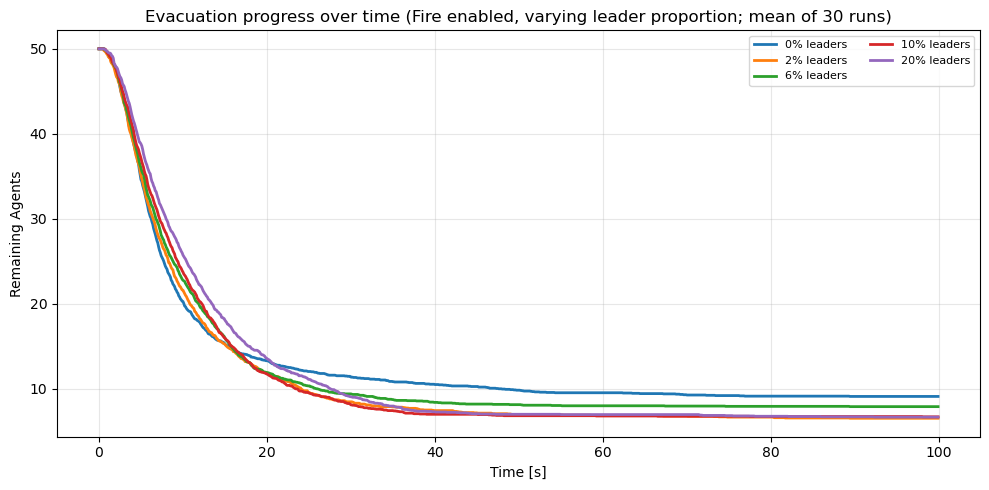

Saved plot to: plots/average_agent_speed_over_time_(fire_enabled,_varying_leader_proportion;_mean_of_30_runs)_Average_Speed.pdf


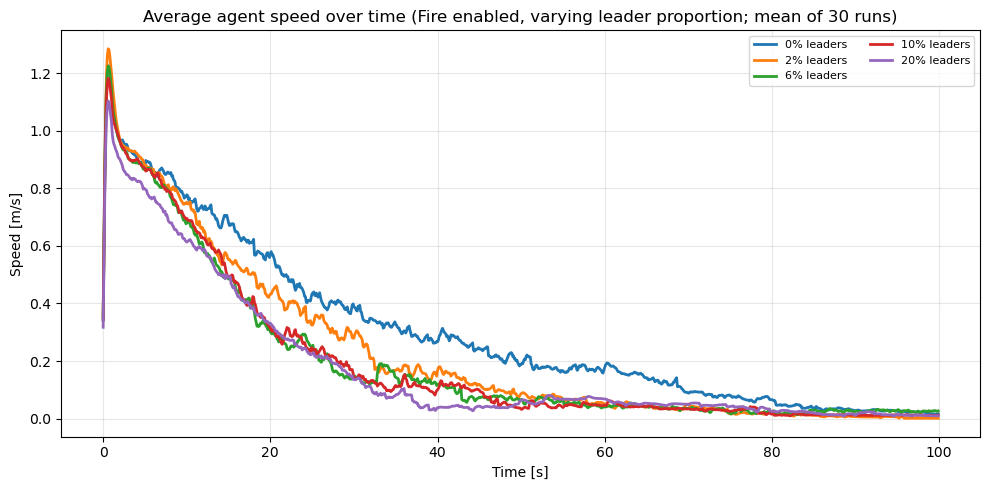

Saved plot to: plots/cumulative_number_of_injured_agents_over_time_(fire_enabled,_varying_leader_proportion;_mean_of_30_runs)_Injured_Total.pdf


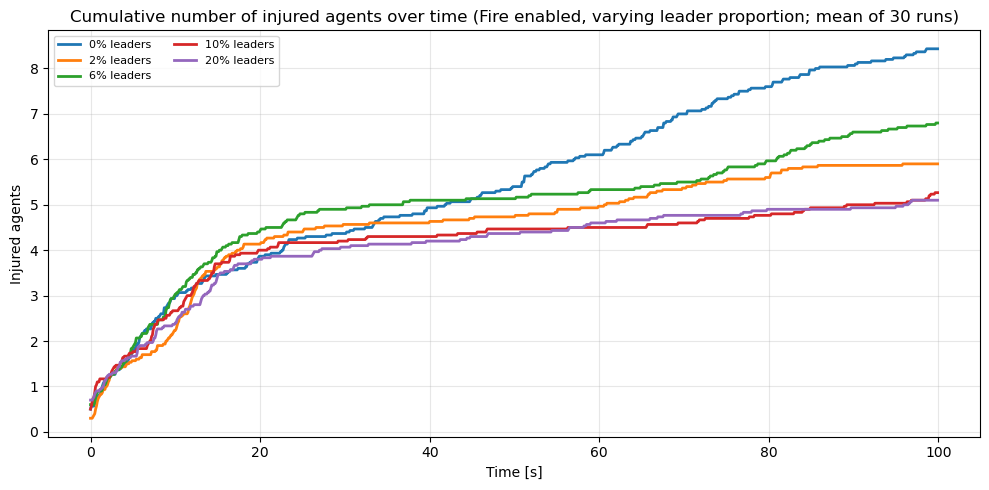

In [9]:
exp_dir = Path("experiments/extended_agents_full_20251020_143838")
combined_model_df = load_combined_model_df(
    exp_dir,
    parameter_name="leader_proportion",
    parameter_values=[0.0, 0.02, 0.06, 0.10, 0.20],
    additional_filters={"fire_enabled": True}
)

save_folder = "plots"
Path(save_folder).mkdir(parents=True, exist_ok=True)

plot_by_parameter(
    combined_model_df,
    "leader_proportion",
    "Agents",
    "Evacuation progress over time (Fire enabled, varying leader proportion; mean of 30 runs)",
    "Remaining Agents",
    save_dir=save_folder
)
plot_by_parameter(
    combined_model_df,
    "leader_proportion",
    "Average_Speed",
    "Average agent speed over time (Fire enabled, varying leader proportion; mean of 30 runs)",
    "Speed [m/s]",
    save_dir=save_folder
)

plot_by_parameter(
    combined_model_df,
    "leader_proportion",
    "Injured_Total",
    "Cumulative number of injured agents over time (Fire enabled, varying leader proportion; mean of 30 runs)",
    "Injured agents",
    save_dir=save_folder
)

## Plot the impact of different exit configurations on evacuation progress, average speed and number of injuries

Loaded experiment: Comprehensive extended agent experiment testing fire, multiple exits, and leadership effects on evacuation dynamics
Date: 2025-10-20T14:38:38.228766
Total runs: 300
Varied parameter(s): fire_enabled, exit_preset, num_exits, leader_proportion, num_leaders, seed, remaining_agents, overall_flow_rate, leaders_evacuated, leaders_remaining, leader_evacuation_rate, leader_flow_rate, injured_total, injured_rate, injured_fire, injured_smoke, injured_pressure, exit0_usage, exit1_usage, exit2_usage, exit_balance
Loaded experiment: Comprehensive extended agent experiment testing fire, multiple exits, and leadership effects on evacuation dynamics
Date: 2025-10-20T14:38:38.228766
Total runs: 300
Varied parameter(s): fire_enabled, exit_preset, num_exits, leader_proportion, num_leaders, seed, remaining_agents, overall_flow_rate, leaders_evacuated, leaders_remaining, leader_evacuation_rate, leader_flow_rate, injured_total, injured_rate, injured_fire, injured_smoke, injured_pressure, 

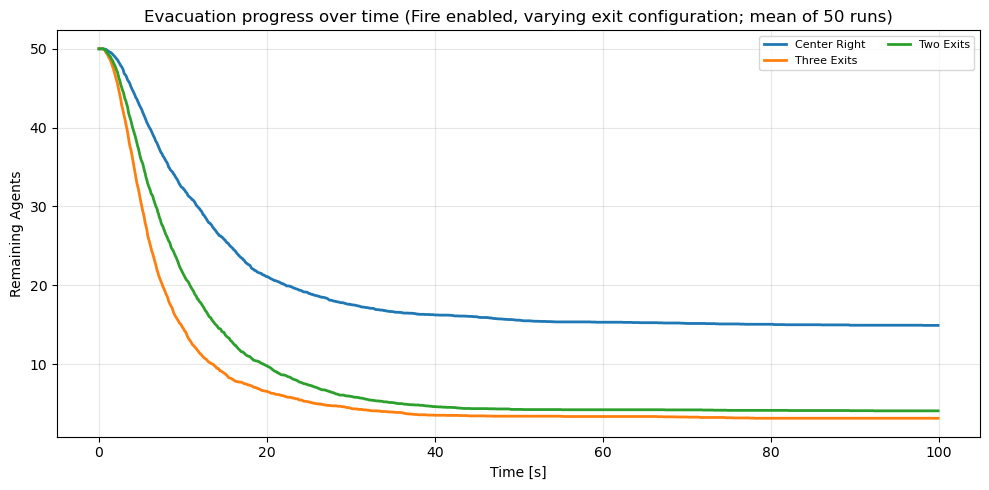

Saved plot to: plots/average_agent_speed_over_time_(fire_enabled,_varying_exit_configuration;_mean_of_50_runs)_Average_Speed.pdf


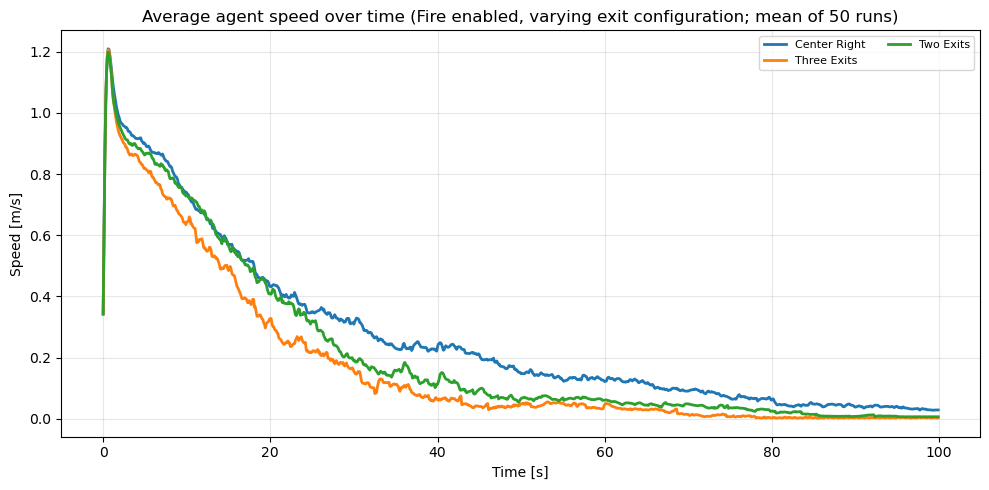

Saved plot to: plots/cumulative_number_of_injured_agents_over_time_(fire_enabled,_varying_exit_configuration;_mean_of_50_runs)_Injured_Total.pdf


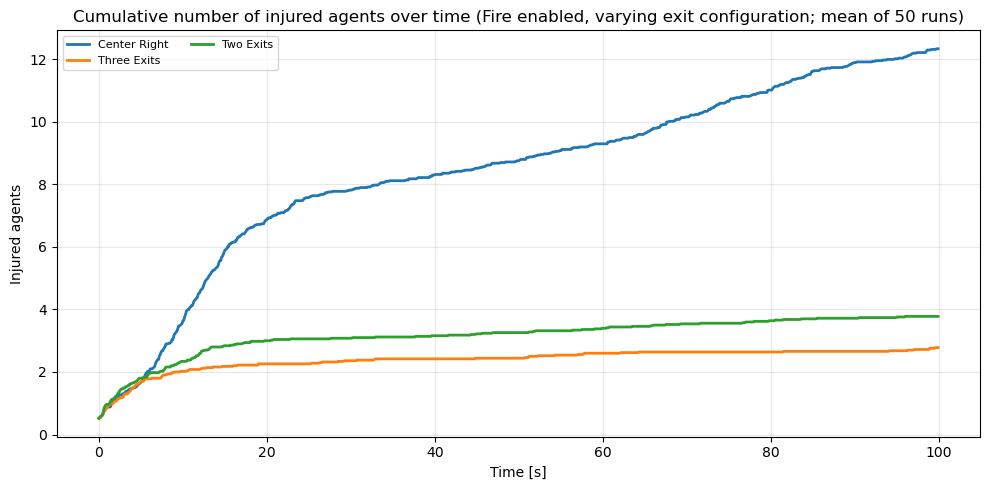

In [10]:
exp_dir = Path("experiments/extended_agents_full_20251020_143838")
combined_model_df = load_combined_model_df(
    exp_dir,
    parameter_name="exit_preset",
    parameter_values=["center_right", "two_exits", "three_exits"],
    additional_filters={"fire_enabled": True}
)
plot_by_parameter(
    combined_model_df,
    "exit_preset",
    "Agents",
    "Evacuation progress over time (Fire enabled, varying exit configuration; mean of 50 runs)",
    "Remaining Agents",
    save_dir=save_folder
)
plot_by_parameter(
    combined_model_df,
    "exit_preset",
    "Average_Speed",
    "Average agent speed over time (Fire enabled, varying exit configuration; mean of 50 runs)",
    "Speed [m/s]",
    save_dir=save_folder
)

plot_by_parameter(
    combined_model_df,
    "exit_preset",
    "Injured_Total",
    "Cumulative number of injured agents over time (Fire enabled, varying exit configuration; mean of 50 runs)",
    "Injured agents",
    save_dir=save_folder
)

- If you want to explore more plots here are the possible model level columns that we record:

In [11]:
display(combined_model_df.columns)

Index(['Agents', 'Average_Speed', 'Exit_Flow_Total', 'Exit0_Flow',
       'Exit1_Flow', 'Exit2_Flow', 'Exit_Balance_Entropy', 'Exit0_Pressure',
       'Exit1_Pressure', 'Exit2_Pressure', 'Followers_Latched',
       'Leaders_Remaining', 'Mean_VisTerm', 'Mean_SmokeExposure',
       'Injured_Total', 'Injured_Fire', 'Injured_Smoke', 'Injured_Press',
       'Std_v0_init', 'Std_vmax', 'Std_radius', 'Std_mass', 'Std_vis',
       'Std_panic0', 'exit_preset', 'run_name'],
      dtype='object')

## Plot the impact of fire conditions

Loaded experiment: Comprehensive extended agent experiment testing fire, multiple exits, and leadership effects on evacuation dynamics
Date: 2025-10-20T14:38:38.228766
Total runs: 300
Varied parameter(s): fire_enabled, exit_preset, num_exits, leader_proportion, num_leaders, seed, remaining_agents, overall_flow_rate, leaders_evacuated, leaders_remaining, leader_evacuation_rate, leader_flow_rate, injured_total, injured_rate, injured_fire, injured_smoke, injured_pressure, exit0_usage, exit1_usage, exit2_usage, exit_balance
              mean_total_time  std_total_time  mean_injured  std_injured    n
fire_enabled                                                                 
False               68.670667       29.906578      2.646667     3.816490  150
True                64.680667       28.821046      6.300000     6.483588  150
Saved plot to: figures/fire_vs_nofire/fire_vs_nofire_total_time.pdf


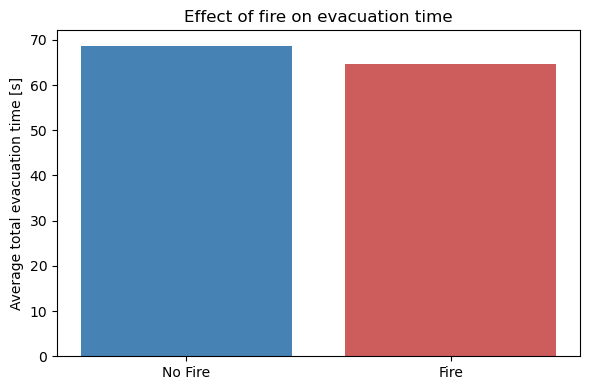

Saved plot to: figures/fire_vs_nofire/fire_vs_nofire_injured.pdf


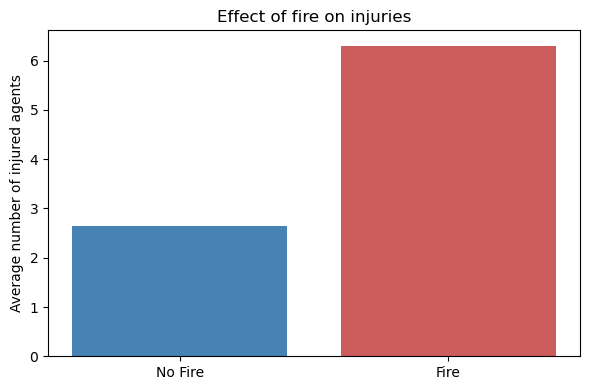

Loaded experiment: Comprehensive extended agent experiment testing fire, multiple exits, and leadership effects on evacuation dynamics
Date: 2025-10-20T14:38:38.228766
Total runs: 300
Varied parameter(s): fire_enabled, exit_preset, num_exits, leader_proportion, num_leaders, seed, remaining_agents, overall_flow_rate, leaders_evacuated, leaders_remaining, leader_evacuation_rate, leader_flow_rate, injured_total, injured_rate, injured_fire, injured_smoke, injured_pressure, exit0_usage, exit1_usage, exit2_usage, exit_balance
Loaded experiment: Comprehensive extended agent experiment testing fire, multiple exits, and leadership effects on evacuation dynamics
Date: 2025-10-20T14:38:38.228766
Total runs: 300
Varied parameter(s): fire_enabled, exit_preset, num_exits, leader_proportion, num_leaders, seed, remaining_agents, overall_flow_rate, leaders_evacuated, leaders_remaining, leader_evacuation_rate, leader_flow_rate, injured_total, injured_rate, injured_fire, injured_smoke, injured_pressure, 

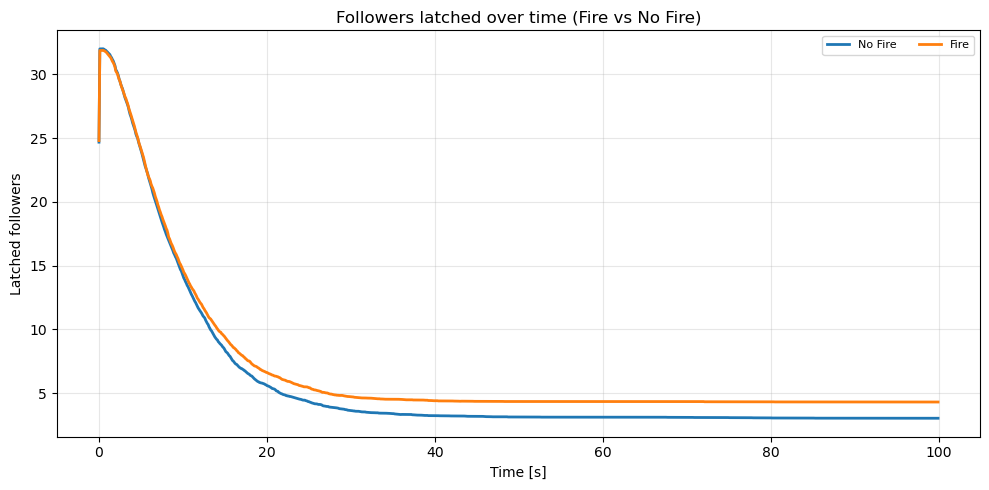

Saved plot to: figures/fire_vs_nofire/visibility_loss_over_time_(fire_vs_no_fire)_Mean_VisTerm.pdf


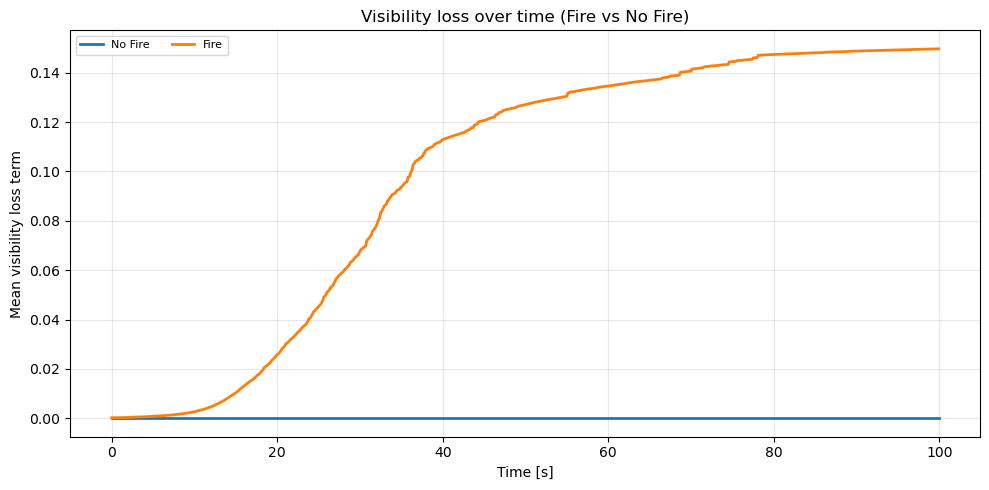

In [ ]:
# --- 1. Load experiment data ---
exp_dir = Path("experiments/extended_agents_full_20251020_143838")
results = load_experiment_results(exp_dir)
detailed = results["detailed_df"]

# --- 2. Scalar comparison: total_time and injured_total (Fire vs No Fire) ---
inj_col = "injured_total" if "injured_total" in detailed.columns else "injured"

scalar_summary = (
    detailed
    .groupby("fire_enabled")
    .agg(
        mean_total_time=("total_time", "mean"),
        std_total_time=("total_time", "std"),
        mean_injured=(inj_col, "mean"),
        std_injured=(inj_col, "std"),
        n=("run", "count")
    )
)
print(scalar_summary)

save_dir = Path("plots")
save_dir.mkdir(parents=True, exist_ok=True)

# --- 2a. Barplot: average total evacuation time ---
plt.figure(figsize=(6, 4))
x = [0, 1]
labels = ["No Fire", "Fire"]
mean_tt = [
    scalar_summary.loc[False, "mean_total_time"],
    scalar_summary.loc[True, "mean_total_time"]
]
plt.bar(x, mean_tt, color=["steelblue", "indianred"])
plt.xticks(x, labels)
plt.ylabel("Average total evacuation time [s]")
plt.title("Effect of fire on evacuation time")
plt.tight_layout()

pdf_path_tt = save_dir / "fire_vs_nofire_total_time.pdf"
plt.savefig(pdf_path_tt, format="pdf", bbox_inches="tight")
print(f"Saved plot to: {pdf_path_tt}")
plt.show()

# --- 2b. Barplot: average number of injured agents ---
plt.figure(figsize=(6, 4))
mean_inj = [
    scalar_summary.loc[False, "mean_injured"],
    scalar_summary.loc[True, "mean_injured"]
]
plt.bar(x, mean_inj, color=["steelblue", "indianred"])
plt.xticks(x, labels)
plt.ylabel("Average number of injured agents")
plt.title("Effect of fire on injuries")
plt.tight_layout()

pdf_path_inj = save_dir / "fire_vs_nofire_injured.pdf"
plt.savefig(pdf_path_inj, format="pdf", bbox_inches="tight")
print(f"Saved plot to: {pdf_path_inj}")
plt.show()

# --- 3. Time series comparison: Followers_Latched & Mean_VisTerm (Fire vs No Fire) ---
combined_fire_df = load_combined_model_df(
    exp_dir,
    parameter_name="fire_enabled",
    parameter_values=[False, True],
    additional_filters=None
)

plot_by_parameter(
    combined_fire_df,
    parameter_name="fire_enabled",
    ycol="Followers_Latched",
    title="Followers latched over time (Fire vs No Fire)",
    ylabel="Latched followers",
    dt=0.1,
    max_steps=1000,
    save_dir=save_dir
)

plot_by_parameter(
    combined_fire_df,
    parameter_name="fire_enabled",
    ycol="Mean_VisTerm",
    title="Visibility loss over time (Fire vs No Fire)",
    ylabel="Mean visibility loss term",
    dt=0.1,
    max_steps=1000,
    save_dir=save_dir
)